# Patient Appointment No-Show Analysis



## Business Problem

Missed medical appointments (No-Shows) reduce clinic efficiency, increase healthcare costs, and limit access to care for other patients. Understanding the factors associated with appointment attendance can help healthcare facilities improve scheduling practices and patient engagement.


## Objective
The objective of this analysis is to:

- Identify factors associated with patient no-shows.
- Explore demographic, clinical, and scheduling characteristics that influence attendance.
- Generate insights that can support appointment management strategies and reduce missed appointments.

### Key Features

 Variable | Description 
----------|-------------|
 **Age** | Patient age in years |
| **Gender** | Patient gender |
| **Scholarship** | Government welfare support indicator |
| **Hypertension** | Hypertension diagnosis |
| **Diabetes** | Diabetes diagnosis |
| **Alcoholism** | Alcohol dependency indicator |
| **Smokes** | Smoking status |
| **Tuberculosis** | Tuberculosis diagnosis |
| **Handicap** | Disability indicator |
| **Sms_Reminder** | Whether appointment reminder was sent |
| **WaitingDays** | Number of days between booking and appointment |
| **AppointmentRegistration** | Date appointment was booked |
| **AppointmentDate** | Scheduled appointment date |
| **DayOfTheWeek** | Day appointment occurs |

# Data Cleaning & Preparation

Before performing any analysis, the dataset was cleaned and transformed to ensure consistency, accuracy, and reliability.

The following preprocessing steps were performed:

- Imported the dataset into Python using Pandas.
- Checked dataset dimensions and data types.
- Examined missing values.
- Identified duplicate records.
- Standardized categorical variables.
- Converted date columns into datetime format.
- Created new analytical Patient Appointment No-Show Analysis
- Verified the dataset was suitable for exploratory analysis and predictive modelling.

These steps improve data quality and ensure valid statistical results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization style
sns.set_theme(style="whitegrid")


In [2]:

df = pd.read_csv("No-show-Issue-Comma-300k.csv")
df.head()

,Age,Gender,AppointmentRegistration,ApointmentData,DayOfTheWeek,Status,Diabetes,Alcoolism,HiperTension,Handcap,Smokes,Scholarship,Tuberculosis,Sms_Reminder,AwaitingTime
0,19,M,2014-12-16T14:46:25Z,2015-01-14T00:00:00Z,Wednesday,Show-Up,0,0,0,0,0,0,0,0,-29
1,24,F,2015-08-18T07:01:26Z,2015-08-19T00:00:00Z,Wednesday,Show-Up,0,0,0,0,0,0,0,0,-1
2,4,F,2014-02-17T12:53:46Z,2014-02-18T00:00:00Z,Tuesday,Show-Up,0,0,0,0,0,0,0,0,-1
3,5,M,2014-07-23T17:02:11Z,2014-08-07T00:00:00Z,Thursday,Show-Up,0,0,0,0,0,0,0,1,-15
4,38,M,2015-10-21T15:20:09Z,2015-10-27T00:00:00Z,Tuesday,Show-Up,0,0,0,0,0,0,0,1,-6


In [3]:
# Index and Datatype 

df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Age                      300000 non-null  int64 
 1   Gender                   300000 non-null  object
 2   AppointmentRegistration  300000 non-null  object
 3   ApointmentData           300000 non-null  object
 4   DayOfTheWeek             300000 non-null  object
 5   Status                   300000 non-null  object
 6   Diabetes                 300000 non-null  int64 
 7   Alcoolism                300000 non-null  int64 
 8   HiperTension             300000 non-null  int64 
 9   Handcap                  300000 non-null  int64 
 10  Smokes                   300000 non-null  int64 
 11  Scholarship              300000 non-null  int64 
 12  Tuberculosis             300000 non-null  int64 
 13  Sms_Reminder             300000 non-null  int64 
 14  AwaitingTime        

In [4]:
# Prints number of rows and columns in dataframe

print(df.shape)

(300000, 15)


In [5]:
# Missing Values

df.isnull().sum()

Age                        0
Gender                     0
AppointmentRegistration    0
ApointmentData             0
DayOfTheWeek               0
Status                     0
Diabetes                   0
Alcoolism                  0
HiperTension               0
Handcap                    0
Smokes                     0
Scholarship                0
Tuberculosis               0
Sms_Reminder               0
AwaitingTime               0
dtype: int64

In [11]:
# Duplicates

def find_duplicates(df):
    seen = set()
    duplicates = set()

    for item in df:
        if item in seen:
            duplicates.add(item)
        else:
            seen.add(item)

    return list(duplicates)
duplicates = find_duplicates(df)
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [12]:
df = df.drop_duplicates()

In [13]:
# Print unique values and counts for all columns

print ("Rows     : " , df.shape[0])
print ("Columns  : " , df.shape[1])
print ("\nFeatures : \n", df.columns.tolist())
print ("\nMissing values :  ", df.isnull().sum().values.sum())
print ("\nUnique values :  \n", df.nunique())

Rows     :  299657
Columns  :  15

Features : 
 ['Age', 'Gender', 'AppointmentRegistration', 'ApointmentData', 'DayOfTheWeek', 'Status', 'Diabetes', 'Alcoolism', 'HiperTension', 'Handcap', 'Smokes', 'Scholarship', 'Tuberculosis', 'Sms_Reminder', 'AwaitingTime']

Missing values :   0

Unique values :  
 Age                           109
Gender                          2
AppointmentRegistration    295425
ApointmentData                534
DayOfTheWeek                    7
Status                          2
Diabetes                        2
Alcoolism                       2
HiperTension                    2
Handcap                         5
Smokes                          2
Scholarship                     2
Tuberculosis                    2
Sms_Reminder                    3
AwaitingTime                  213
dtype: int64


In [14]:
print(df['Sms_Reminder'].value_counts())

Sms_Reminder
1    170645
0    128213
2       799
Name: count, dtype: int64


In [15]:
# observation - handicap has distinct values, for easy analysis, this will be worked on to make it binary

## Findings

- No major missing value issues detected.
- Several column names contained typographical errors.
- Date fields were stored as text.
- Negative age values existed and were considered invalid.
- Waiting time contained negative values requiring correction.
- SMS reminder variable contained three categories (0,1,2) requiring standardization.

### Data Cleaning

In [16]:

# Several columns were renamed for consistency and readability

df = df.rename(columns={
    'ApointmentData': 'AppointmentDate',
    'Alcoolism': 'Alcoholism',
    'HiperTension': 'Hypertension',
    'Handcap': 'Handicap',
    'AwaitingTime' : 'WaitingDays'
})
print(df.columns.tolist())
print("Columns renamed successfully.")

['Age', 'Gender', 'AppointmentRegistration', 'AppointmentDate', 'DayOfTheWeek', 'Status', 'Diabetes', 'Alcoholism', 'Hypertension', 'Handicap', 'Smokes', 'Scholarship', 'Tuberculosis', 'Sms_Reminder', 'WaitingDays']
Columns renamed successfully.


In [17]:
# Standardization
# The following fields were standardized: Status, Gender, DayOfTheWeek
# This ensures consistency during analysis and visualization.


df['Status'] = df['Status'].str.strip().str.title()

df['Gender'] = df['Gender'].str.upper().str.strip()

df['DayOfTheWeek'] = df['DayOfTheWeek'].str.strip()

print(df['Status'].unique())
print(df['Gender'].unique())
print(df['DayOfTheWeek'].unique())

['Show-Up' 'No-Show']
['M' 'F']
['Wednesday' 'Tuesday' 'Thursday' 'Friday' 'Monday' 'Saturday' 'Sunday']


In [18]:
# Date Conversion
# Converted: AppointmentRegistration and AppointmentDate from string format to datetime format to enable temporal analysis 

df['AppointmentRegistration'] = pd.to_datetime(df['AppointmentRegistration'])
df['AppointmentDate'] = pd.to_datetime(df['AppointmentDate'])

# Check the data types to confirm the change

print(df[['AppointmentRegistration', 'AppointmentDate']].dtypes)

AppointmentRegistration    datetime64[ns, UTC]
AppointmentDate            datetime64[ns, UTC]
dtype: object


In [19]:
# SMS Reminder Transformation
# 0 = No reminder, 1 = Reminder sent, 2 = Multiple reminders sent

# For simplicity: 0 → No Reminder, 1 and 2 → Reminder Sent


df['Sms_Reminder'] = (df['Sms_Reminder'] > 0).astype(int)
print(df['Sms_Reminder'].value_counts())

Sms_Reminder
1    171444
0    128213
Name: count, dtype: int64


In [20]:
#  Invalid Age Removal
#  Negative ages were removed because they are not logically possible.

initial_rows = df.shape[0]
df = df[df['Age'] >= 0]
dropped_rows = initial_rows - df.shape[0]
print(f"Dropped {dropped_rows} rows due to negative age.")



Dropped 6 rows due to negative age.


In [21]:
# Waiting Time Correction
# Negative waiting times were converted to absolute values to represent actual elapsed days.

df['WaitingDays'] = df['WaitingDays'].abs()

## Feature Engineering

To improve analytical insights, several new variables were created.

#### Appointment Features

Extracted:

- Registration Year
- Registration Month
- Registration Weekday
- Appointment Month
- Appointment Weekday

Purpose:
To investigate temporal patterns in appointment attendance.

#### Waiting Time Features

#### Created Feature
Waiting_Days 
Waiting_Group Categorizes patients based on the number of waiting days between appointment booking and the scheduled appointment. 

#### Waiting Group Categories

| Group | Waiting Days |
|-------|--------------|
| **Same_Day** | 0 days |
| **Within_Week** | 1–7 days |
| **Within_Month** | 8–30 days |
| **1_to_3_Months** | 31–90 days |
| **Above_3_Months** | More than 90 days |

Purpose:
Longer waiting periods may increase the likelihood of missed appointments.

#### Age Groups

Patients were categorized into:

- Child
- Teen
- Young Adult
- Adult
- Middle Aged
- Senior

Purpose:
Attendance behavior may differ across age categories.

#### Disease Burden Metrics
Disease_Count

Total number of chronic conditions present.

#### Multiple_Conditions

A patient that has two or more chronic diseases.

#### Health_Risk_Score

Combined score based on:

- Diabetes
- Hypertension
- Tuberculosis
- Alcoholism
- Smoking

Purpose:
To assess whether health burden influences appointment attendance.



In [22]:
# Ensure both columns are in datetime format
df['AppointmentRegistration'] = pd.to_datetime(df['AppointmentRegistration'])
df['AppointmentDate'] = pd.to_datetime(df['AppointmentDate'])

# Create Waiting_Days column
df['Waiting_Days'] = (
    df['AppointmentDate'] - df['AppointmentRegistration']
).dt.days

# Preview the new column
df[['AppointmentRegistration', 'AppointmentDate', 'Waiting_Days']].head()

,AppointmentRegistration,AppointmentDate,Waiting_Days
0,2014-12-16 14:46:25+00:00,2015-01-14 00:00:00+00:00,28
1,2015-08-18 07:01:26+00:00,2015-08-19 00:00:00+00:00,0
2,2014-02-17 12:53:46+00:00,2014-02-18 00:00:00+00:00,0
3,2014-07-23 17:02:11+00:00,2014-08-07 00:00:00+00:00,14
4,2015-10-21 15:20:09+00:00,2015-10-27 00:00:00+00:00,5


In [23]:
# Registration Date Features

df['AppointmentRegistration'] = pd.to_datetime(df['AppointmentRegistration'])

df['Registration_Year'] = df['AppointmentRegistration'].dt.year
df['Registration_Month'] = df['AppointmentRegistration'].dt.month
df['Registration_Day'] = df['AppointmentRegistration'].dt.day
df['Registration_Hour'] = df['AppointmentRegistration'].dt.hour
df['Registration_Weekday'] = df['AppointmentRegistration'].dt.day_name()

In [24]:
#Appointment Date Features

df['AppointmentDate'] = pd.to_datetime(df['AppointmentDate'])

df['Appointment_Month'] = df['AppointmentDate'].dt.month
df['Appointment_Day'] = df['AppointmentDate'].dt.day
df['Appointment_Weekday'] = df['AppointmentDate'].dt.day_name()
df['Appointment_Week'] = df['AppointmentDate'].dt.isocalendar().week

#Create Weekend Feature

df['Is_Weekend'] = (
    df['Appointment_Weekday']
    .isin(['Saturday', 'Sunday'])
    .astype(int)
)

In [25]:
#Waiting Time Engineering 
 

df['Waiting_Group'] = pd.cut(
    df['WaitingDays'],
    bins=[-1,0,7,30,90,365],
    labels=[
        'Same_Day',
        'Within_Week',
        'Within_Month',
        '1_to_3_Months',
        'Above_3_Months'
    ]
)

# Long Wait Indicator

df['Long_Wait'] = (df['WaitingDays'] > 30).astype(int)

In [26]:
# Age Engineering
# Age Groups

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0,12,18,35,50,65,120],
    labels=[
        'Child',
        'Teen',
        'Young_Adult',
        'Adult',
        'Middle_Aged',
        'Senior'
    ]
)

In [27]:
# Chronic Disease Count
#

disease_cols = [
    'Diabetes',
    'Hypertension',
    'Tuberculosis',
    'Alcoholism',
    'Smokes'
]

df['Disease_Count'] = df[disease_cols].sum(axis=1)

# Multiple Conditions Flag

df['Multiple_Conditions'] = (
    df['Disease_Count'] >= 2
).astype(int)

In [28]:
# Health Risk Score
# Combine risk-related conditions.

risk_cols = [
    'Diabetes',
    'Hypertension',
    'Tuberculosis'
]

df['Health_Risk_Score'] = df[risk_cols].sum(axis=1)

### Exploratory Data Analysis (EDA)


## univariate

### Univariate Analysis

Examined:

- Appointment status distribution
- Age distribution
- Gender distribution
- Appointment timing
- Waiting days
- SMS reminders
- Chronic disease prevalence

Purpose:
To understand the overall structure of the dataset.                                                             

Status
Show-Up    209040
No-Show     90611
Name: count, dtype: int64
Status
Show-Up    69.761155
No-Show    30.238845
Name: proportion, dtype: float64


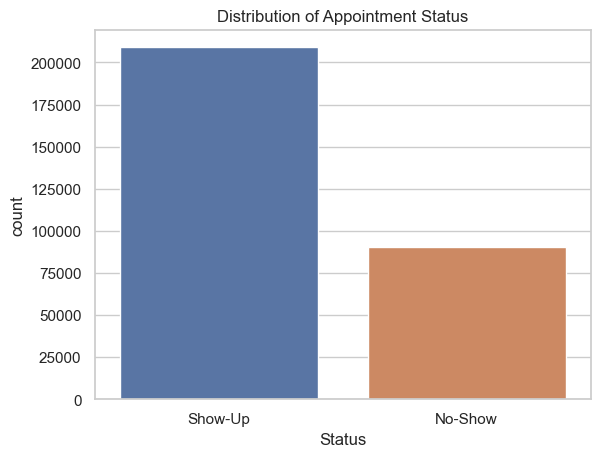

In [29]:
# Target Variable 
# Distribution of No-Show / Status

print(df['Status'].value_counts())
print(df['Status'].value_counts(normalize=True) * 100)

sns.countplot(x='Status', data=df)
plt.title("Distribution of Appointment Status")

# Appointment Status Distribution

plt.show()

#### Appointment Status Distribution

##### Finding

- The majority (70%) of appointments were attended (Show-Up).
- A considerably smaller proportion (30%)of patients missed their appointments (No-Show).

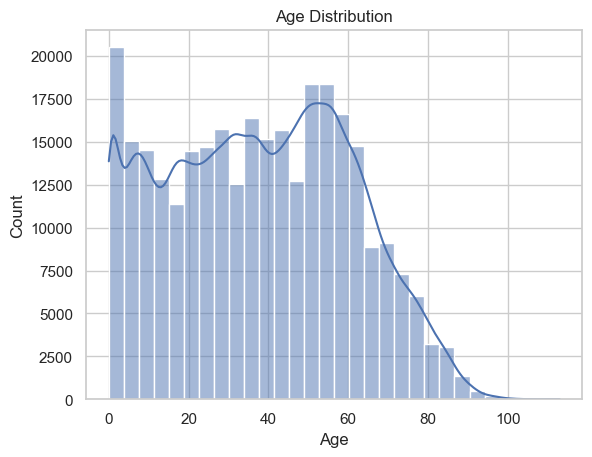

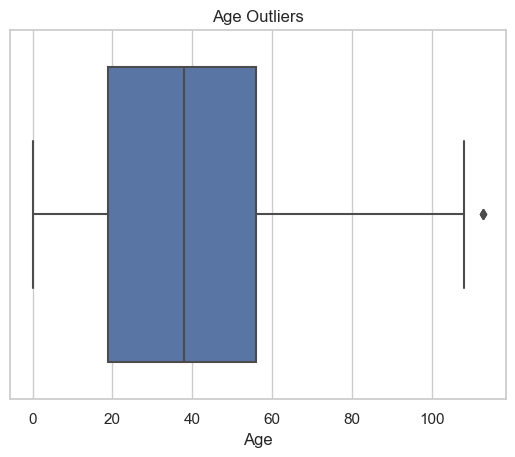

In [30]:
# Age Distribution
df['Age'].describe()

sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


sns.boxplot(x=df['Age'])
plt.title("Age Outliers")
plt.show()


#### Age Distribution

##### Finding

- Most patients are young and middle-aged adults.
- The age distribution is right-skewed, with fewer elderly patients.
- The boxplot shows a few older-age outliers, but they appear to be valid observations rather than errors.

##### Insight

- Healthcare utilization is concentrated among younger adults.
- Age may influence appointment attendance and would be evaluated as a predictor.

Gender
F    200299
M     99352
Name: count, dtype: int64


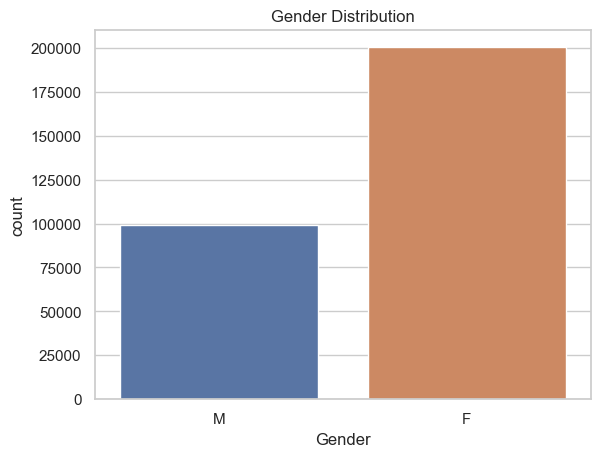

In [31]:
# Gender Distribution

print(df['Gender'].value_counts())
sns.countplot(x='Gender', data=df)

# Age Distribution

plt.title("Gender Distribution")
plt.show()

#### Gender Distribution

##### Finding

- Female patients significantly outnumber male patients.

##### Insight

- Women appear to use healthcare services more frequently than men in this dataset.
- Gender may have some relationship with appointment attendance and warrants further investigation.

DayOfTheWeek
Wednesday    63403
Tuesday      62719
Thursday     60171
Monday       59258
Friday       52701
Saturday      1393
Sunday           6
Name: count, dtype: int64


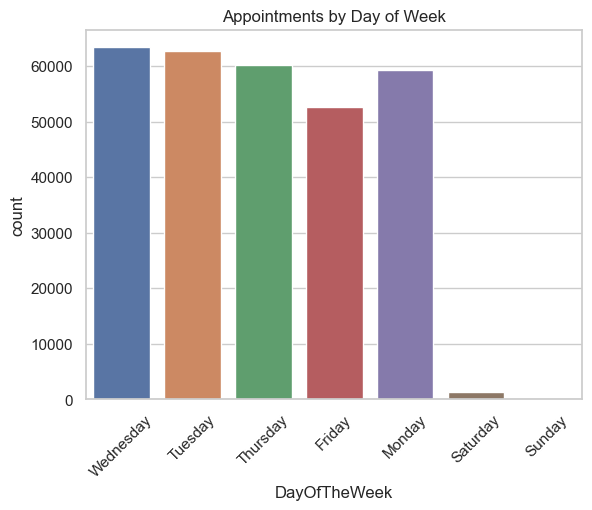

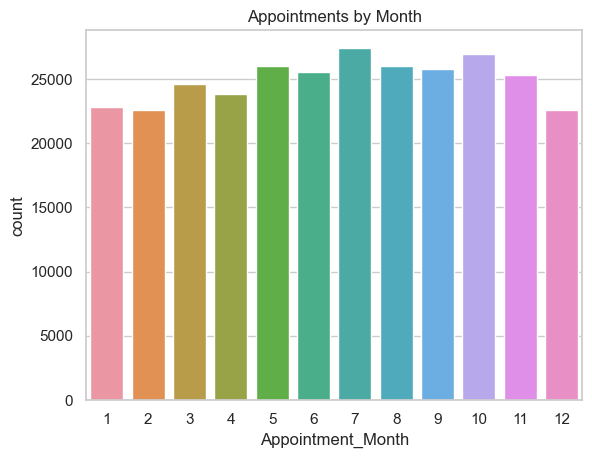

In [32]:
# Appointment Timing

print(df['DayOfTheWeek'].value_counts())

sns.countplot(x='DayOfTheWeek', data=df)
plt.title("Appointments by Day of Week")
plt.xticks(rotation=45)
plt.show()

# Appointment Month

sns.countplot(x='Appointment_Month', data=df)
plt.title("Appointments by Month")
plt.show()

#### Appointment Day of Week

##### Finding

- Appointments are fairly evenly distributed across Monday to Friday.
- Very few appointments occur on Saturday, and virtually none on Sunday.

##### Insight

- Healthcare facilities primarily operate during weekdays.
- There is no obvious day with exceptionally high appointment volume.


#### Appointment Month Distribution

##### Finding

- Appointment counts remain relatively consistent across the recorded months.
- Minor fluctuations exist but no month dominates the dataset.

##### Insight

- There is little evidence of strong seasonal variation in appointment scheduling.

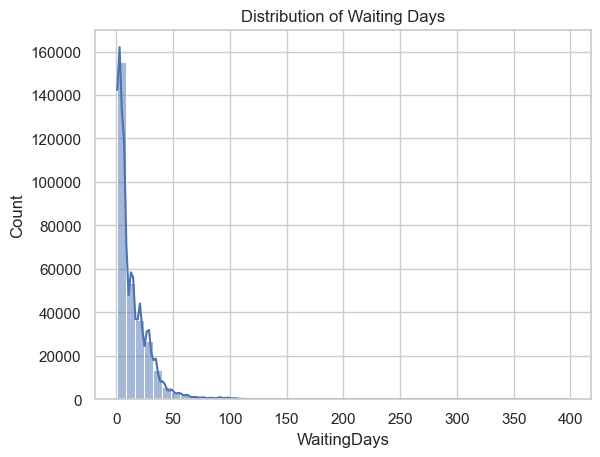

In [33]:
# Awaiting Time

df['WaitingDays'].describe()

sns.histplot(df['WaitingDays'], bins=50, kde=True)
plt.title("Distribution of Waiting Days")
plt.show()


#### Waiting Time (Days Between Scheduling and Appointment)

##### Finding

- Waiting time is highly right-skewed.
Most appointments occur within a short waiting period.
A small number of appointments have extremely long waiting times.

##### Insight

- Most patients receive appointments quickly.
- Long waiting periods are uncommon but may contribute to missed appointments.

Sms_Reminder
1    171439
0    128212
Name: count, dtype: int64


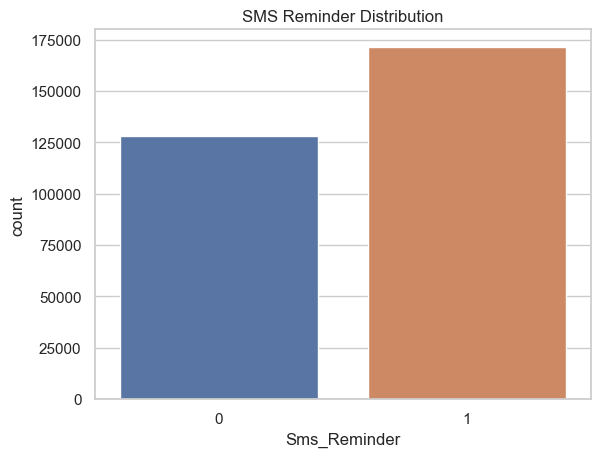

In [34]:
#SMS Reminder
#

print(df['Sms_Reminder'].value_counts())

sns.countplot(x='Sms_Reminder', data=df)
plt.title("SMS Reminder Distribution")
plt.show()

#### SMS Reminder Distribution

##### Finding

- More patients received SMS reminders than those who did not
- Very few appointments occur on Saturday, and virtually none on Sunday.

##### Insight

- SMS reminders are widely used in the healthcare system.
- Further analysis is needed to determine whether reminders reduce no-show rates.

Hypertension    64715
Diabetes        23363
Tuberculosis      135
dtype: int64


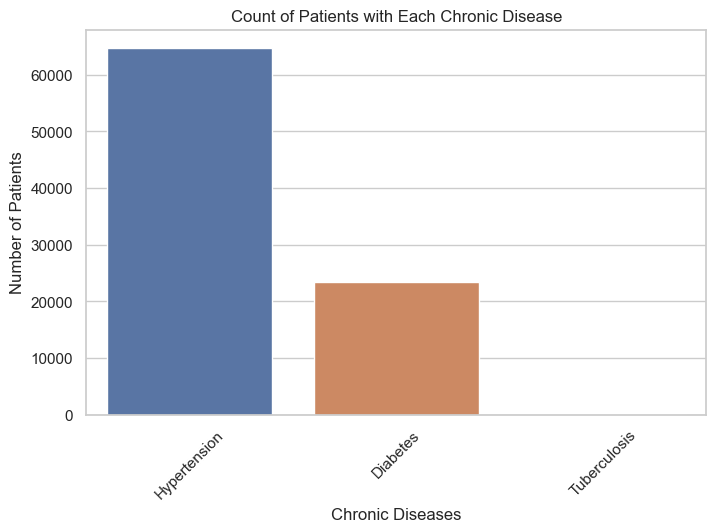

In [35]:
# Chronic Disease Variables


# Chronic disease columns
disease_cols = [
    'Diabetes',
    'Hypertension',
    'Tuberculosis'
]

# Count of patients with each disease (sum of 1's)
disease_counts = df[disease_cols].sum().sort_values(ascending=False)

print(disease_counts)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    x=disease_counts.index,
    y=disease_counts.values
)
plt.title('Count of Patients with Each Chronic Disease')
plt.xlabel('Chronic Diseases')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

#### Appointment Day of Week

##### Finding

- There is a substantial imbalance in the distribution of chronic diseases, with hypertension accounting for the majority of recorded chronic conditions

##### Insight

- The high prevalence of hypertension suggests that cardiovascular-related conditions are a major health burden among the patient population. Healthcare providers should prioritize hypertension screening, monitoring, and management.

Waiting_Group
Within_Week       144254
Within_Month      122747
1_to_3_Months      31003
Above_3_Months      1646
Same_Day               0
Name: count, dtype: int64


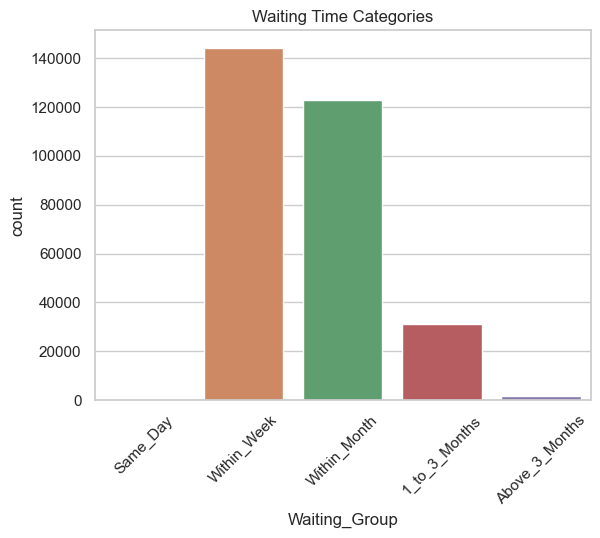

In [36]:
# Waiting Time Groups
#

print(df['Waiting_Group'].value_counts())

sns.countplot(x='Waiting_Group', data=df)
plt.title("Waiting Time Categories")
plt.xticks(rotation=45)
plt.show()

###  Overall Univatiate EDA Summary


- The exploratory analysis reveals several important characteristics of the dataset:
- Most appointments are successfully attended.
- Female patients make up a larger share of healthcare visits.
- The patient population is primarily composed of young and middle-aged adults.
- Appointment scheduling is concentrated on weekdays.
- Waiting times are generally short, although a few appointments experience substantial delays.
- SMS reminders are commonly sent to patients.
- Most patients do not have chronic diseases.
- Waiting periods of one week to one month are the most common scheduling intervals.

#### Waiting Time Categories

##### Finding

- Most appointments fall into:
-   Within One Week
-   Within One Month

##### Insight

- Appointment scheduling is generally efficient.
- Extended waiting periods are relatively rare.

 ## Bivariate Exploratory Data  Analysis (EDA)


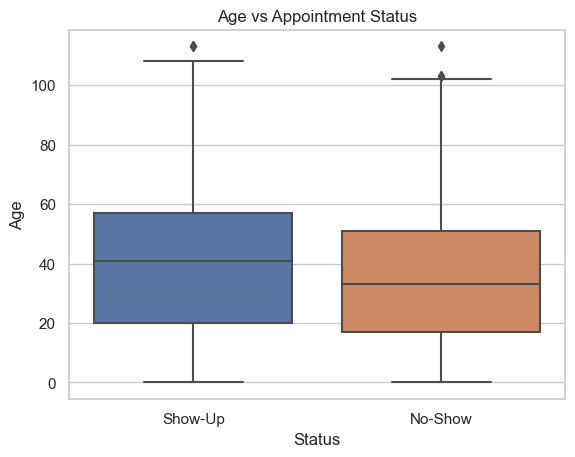

In [37]:
df.groupby('Status')['Age'].describe()


sns.boxplot(x='Status', y='Age', data=df)
plt.title("Age vs Appointment Status")
plt.show()

# Are younger or older patients more likely to miss appointments?
# Compare median ages between groups.

#### Age vs Appointment Status

##### Findings
- The age distributions of Show-Up and No-Show patients are very similar.
- Both groups have comparable median ages (around the mid-30s).
- There is a wide spread of ages in both groups, ranging from - - infants to over 100 years.
- Several elderly outliers appear in both categories.

##### Insights
- Age alone does not appear to be a strong predictor of appointment attendance.
- Since the distributions largely overlap, additional factors such as waiting time, reminders, or scheduling characteristics are likely to have a greater influence on no-show behavior.
- Predictive models may gain little benefit from using age as the sole predictor but could benefit when age is combined with other variables.

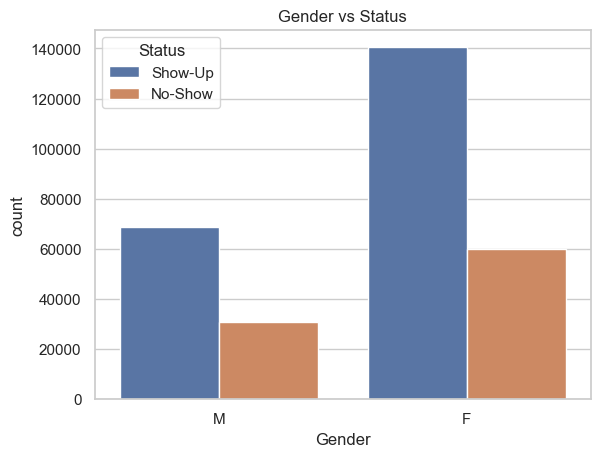

In [38]:
# Gender vs Status

pd.crosstab(df['Gender'], df['Status'])
pd.crosstab(
    df['Gender'],
    df['Status'],
    normalize='index'
) * 100

sns.countplot(x='Gender', hue='Status', data=df)
plt.title("Gender vs Status")
plt.show()


#### Age vs Appointment Status

##### Findings
- Female patients account for the majority of appointments.
- More females both attended and missed appointments compared to males.
- In both genders, the number of patients who attended appointments is substantially higher than those who missed them.

##### Insights
- The higher number of female no-shows is largely explained by females making more appointments overall.
- Gender alone does not appear to strongly influence attendance.
- Since attendance patterns are similar across both genders, gender may have relatively low predictive importance.

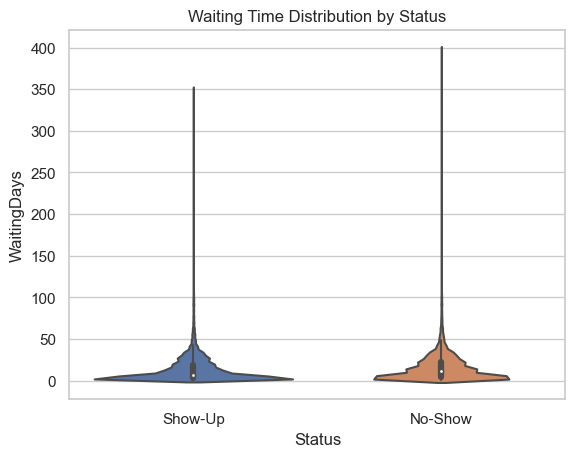

In [39]:
# AwaitingTime vs Status

# Longer waiting periods → higher no-show rates.

df.groupby('Status')['WaitingDays'].describe()


sns.violinplot(
    x='Status',
    y='WaitingDays',
    data=df
)
plt.title("Waiting Time Distribution by Status")
plt.show()

#### Waiting Time vs Appointment Status

##### Findings
- Most appointments have relatively short waiting periods.
- Both Show-Up and No-Show groups exhibit long waiting-time outliers.
- The No-Show distribution appears slightly more spread toward longer waiting times.

##### Insights
- Longer waiting periods may contribute to missed appointments.
- Patients scheduled far into the future may forget, lose interest, or experience changing circumstances.
- Waiting time is likely a more informative predictor of appointment attendance than demographic variables.

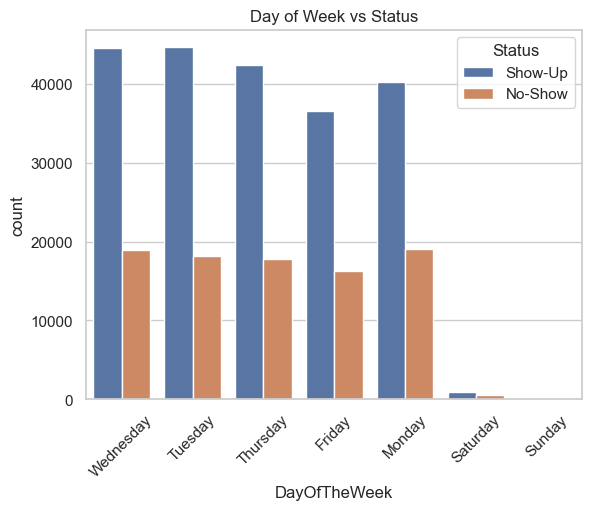

In [40]:
# DayOfTheWeek vs Status


sns.countplot(
    x='DayOfTheWeek',
    hue='Status',
    data=df
)
plt.xticks(rotation=45)
plt.title("Day of Week vs Status")
plt.show()

#### Day of Week vs Appointment Status

##### Findings
- Most appointments occur between Monday and Friday.
- Saturday has very few appointments, while Sunday has almost none.
- Show-Up counts exceed No-Show counts on every weekday.
- Friday appears to have a relatively higher proportion of no-shows compared to some other weekdays.

##### Insights
- Appointment scheduling is concentrated on weekdays.
- The day of the week may have a moderate influence on attendance.
- Friday appointments may require additional reminders or scheduling adjustments if higher no-show rates persist.

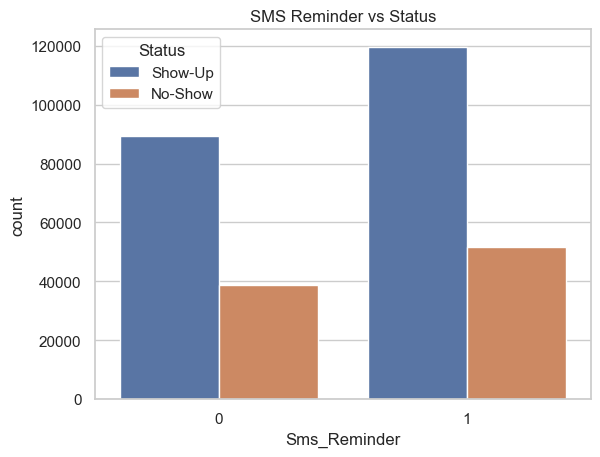

In [41]:
# Sms_Reminder vs Status
# Determine whether reminders reduce missed appointments.

sns.countplot(
    x='Sms_Reminder',
    hue='Status',
    data=df
)
plt.title("SMS Reminder vs Status")
plt.show()

#### SMS Reminder vs Appointment Status

##### Findings
- Most patients received SMS reminders.
- Patients with SMS reminders still recorded a substantial number of no-shows.
- Show-Up counts remain higher than No-Show counts regardless of reminder status.

##### Insights
- Sending an SMS reminder alone does not eliminate missed appointments.
- Reminder effectiveness may depend on timing, message quality, or patient-specific factors.
- SMS reminders should be combined with other interventions such as shorter waiting times or follow-up calls.

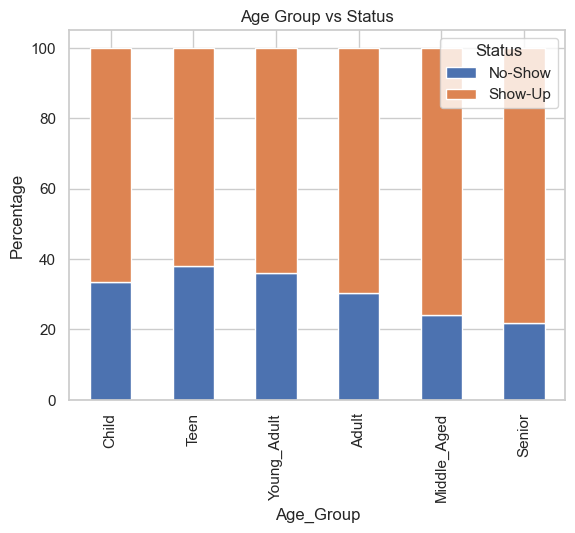

In [42]:
# Age Group vs Status
#
(
    pd.crosstab(
        df['Age_Group'],
        df['Status'],
        normalize='index'
    ) * 100
).plot(
    kind='bar',
    stacked=True
)

plt.title("Age Group vs Status")
plt.ylabel("Percentage")
plt.show()

#### Age Group vs Appointment Status

##### Findings
- Across every age group, Show-Up patients outnumber No-Show patients.
- Young adults and adults exhibit relatively higher proportions of no-shows.
- Older adults and senior patients tend to have higher attendance rates.

##### Insights
- Middle-aged patients may face work or family commitments that increase missed appointments.
- Older patients may prioritize healthcare more consistently.
- Age categories provide more meaningful information than raw age values.

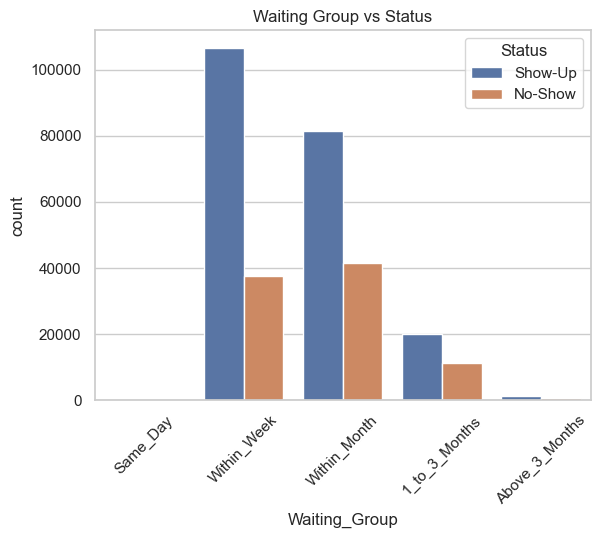

In [43]:
# Waiting Group vs Status
#
sns.countplot(
    x='Waiting_Group',
    hue='Status',
    data=df
)
plt.xticks(rotation=45)
plt.title("Waiting Group vs Status")
plt.show()

#### Waiting Group vs Appointment Status

##### Findings
- Most appointments fall within Within Week and Within Month waiting groups.
- Longer waiting periods are associated with a larger number of no-shows.
- Same-day appointments have very few no-shows.
- Very long waiting periods (>3 months) occur infrequently.

##### Insights
- Waiting time is one of the strongest factors associated with appointment attendance.
- Shorter waiting periods encourage better attendance.
- Reducing appointment delays could significantly decrease no-show rates.

### Overall Bivariate EDA Summary

##### Key Findings

- Waiting time shows the strongest relationship with appointment attendance.
- Waiting group is statistically associated with appointment status.
- Age has little direct influence on attendance.
- Gender does not substantially affect attendance patterns.
- SMS reminders alone are insufficient to prevent no-shows.
- Older patients generally attend appointments more consistently.
- Weekday scheduling may have a moderate effect, with some days showing relatively higher no-show rates.

##### Overall Insights

- The bivariate analysis suggests that appointment-related operational factors (particularly waiting time) have a stronger impact on no-show behavior than patient demographic characteristics such as age or gender. 

- Healthcare facilities could reduce missed appointments by shortening waiting times, optimizing scheduling practices, and enhancing reminder strategies rather than relying solely on demographic targeting. 


## Inferential (Statistical) Analysis

In [44]:
# Convert Gender and Status to Binary (overwriting original columns)

# Gender: M = 1, F = 0
df['Gender'] = df['Gender'].map({'M': 1, 'F': 0})

# Status: No-Show = 1, Show-Up = 0   (recommended for modeling)
df['Status'] = df['Status'].map({'No-Show': 1, 'Show-Up': 0})

# Verify the conversion
print("After Conversion:")
print(df[['Gender', 'Status']].head())
print("\nGender Value Counts:")
print(df['Gender'].value_counts())
print("\nStatus Value Counts:")
print(df['Status'].value_counts())


After Conversion:
   Gender  Status
0       1       0
1       0       0
2       0       0
3       1       0
4       1       0

Gender Value Counts:
Gender
0    200299
1     99352
Name: count, dtype: int64

Status Value Counts:
Status
0    209040
1     90611
Name: count, dtype: int64


In [45]:
# Create dataframe for correlation
corr_df = df[
    [
        'Age',
        'Waiting_Days',
        'Gender',
        'Hypertension',
        'Diabetes',
        'Alcoholism',
        'Handicap',
        'Sms_Reminder',
        'Status'
    ]
]

# Calculate correlation matrix
corr_matrix = corr_df.corr(method='pearson')

# Display
corr_matrix.round(2)

,Age,Waiting_Days,Gender,Hypertension,Diabetes,Alcoholism,Handicap,Sms_Reminder,Status
Age,1.00,-0.00,-0.10,0.51,0.29,0.07,0.08,-0.06,-0.10
Waiting_Days,-0.00,1.00,-0.01,-0.04,-0.02,-0.03,-0.01,0.24,0.07
Gender,-0.10,-0.01,1.00,-0.05,-0.02,0.09,0.03,-0.03,0.01
Hypertension,0.51,-0.04,-0.05,1.00,0.42,0.07,0.08,-0.05,-0.06
Diabetes,0.29,-0.02,-0.02,0.42,1.00,0.02,0.06,-0.03,-0.03
Alcoholism,0.07,-0.03,0.09,0.07,0.02,1.00,0.02,-0.02,0.03
Handicap,0.08,-0.01,0.03,0.08,0.06,0.02,1.00,-0.02,-0.01
Sms_Reminder,-0.06,0.24,-0.03,-0.05,-0.03,-0.02,-0.02,1.00,-0.00
Status,-0.10,0.07,0.01,-0.06,-0.03,0.03,-0.01,-0.00,1.00


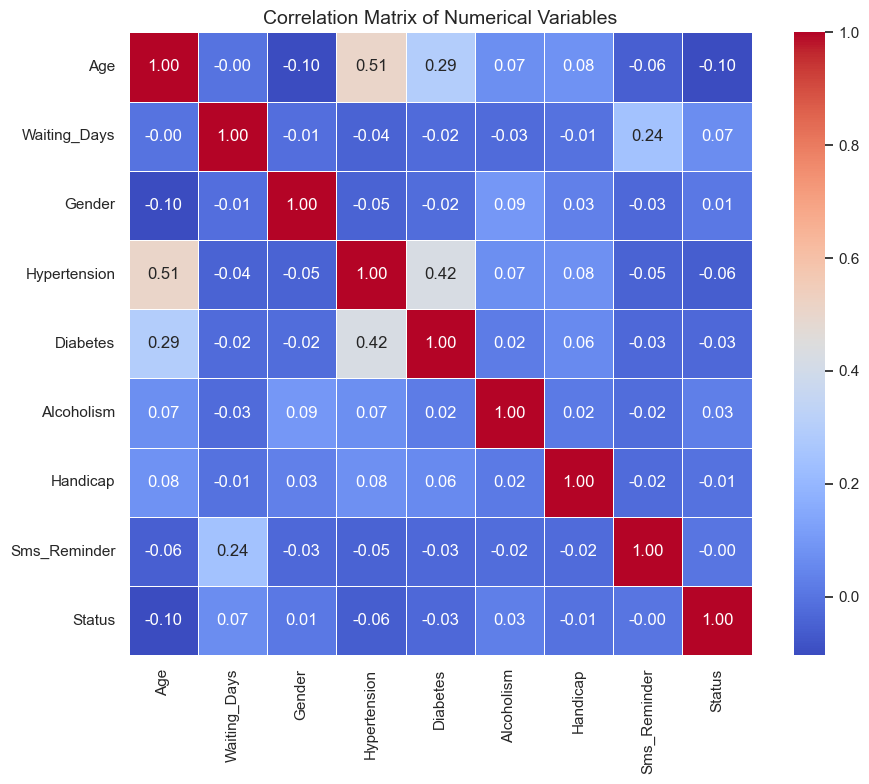

In [46]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Numerical Variables", fontsize=14)
plt.tight_layout()
plt.show()

### Correlation Analysis Insights

-  The heatmap showed that most predictor variables had weak correlations with appointment attendance (Status).
Waiting_Days exhibited the strongest relationship with attendance, suggesting that longer waiting periods are associated with a higher likelihood of missing appointments.

- Chronic conditions such as hypertension and diabetes showed only weak positive associations with appointment attendance.
No pair of predictor variables exhibited a high correlation (e.g., |r| ≥ 0.80), indicating that multicollinearity is unlikely to be a concern.

- Overall, the correlation analysis suggests that no single numerical variable strongly explains appointment attendance, implying that patient no-show behavior is influenced by multiple interacting factors.

### Conclusion

This study analyzed hospital appointment attendance patterns to identify factors associated with patient no-shows. Data cleaning and feature engineering produced reliable variables such as waiting time, waiting groups, age groups, chronic disease count, and health risk score for further analysis.

Exploratory analysis revealed that most patients attended their appointments, although a substantial proportion still missed scheduled visits. Waiting time emerged as one of the strongest factors associated with appointment attendance, with longer waiting periods generally corresponding to higher no-show rates. Appointment attendance also varied across age groups, indicating that patient age influences attendance behavior. Female patients represented a larger share of appointments, but gender showed only a weak relationship with no-show status. Similarly, chronic conditions such as hypertension and diabetes exhibited little direct correlation with attendance.

Correlation analysis indicated that most predictor variables had weak linear relationships with appointment status, suggesting that patient no-shows are influenced by multiple interacting factors rather than a single characteristic. Overall, waiting time appears to be the most practically important variable for predicting missed appointments.

The findings demonstrate that reducing appointment delays and strengthening patient engagement strategies could significantly improve attendance rates and optimize hospital resource utilization.

### Recommendations

1. Reduce Waiting Time - Hospitals should minimize the interval between appointment scheduling and appointment dates, as longer waiting periods are associated with increased no-show rates.

2. Enhance Reminder Systems - SMS reminders should be optimized by sending reminders closer to appointment dates and considering multiple reminders for patients with long waiting periods.

3. Prioritize High-Risk Patients - Patients scheduled several weeks or months ahead should receive additional follow-up calls or reminder messages because they have a higher likelihood of missing appointments.

4. Introduce Easy Rescheduling - Provide convenient channels for patients to cancel or reschedule appointments instead of simply failing to attend.

5. Monitor No-Show Trends - Hospital administrators should continuously monitor appointment attendance rates and waiting-time distributions through dashboards to identify emerging patterns and evaluate interventions.

6. Improve Appointment Scheduling Policies - Where possible, prioritize earlier appointment slots for patients facing extended waiting periods to reduce the probability of missed appointments.